In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score, precision_score, confusion_matrix
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import ast
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [4]:
# Note: Only 50% of the total comments were used due to computational constraints
df = pd.read_csv('comments_with_indobert_embeddings.csv', sep=';')

In [5]:
df.head(5)

,video_id,video_title,comment,label,comment_embedding,label_embedding
0,ZshDHBFmkqU,Jangan salah pilih kotak😅,Itu yg bikin kotaknya sendiriya gampang tau lo...,No Online Gambling Promotion,"[0.7403849959373474, -1.3455597162246704, -1.2...","[-0.46382713317871094, -0.4860941171646118, -2..."
1,ZshDHBFmkqU,Jangan salah pilih kotak😅,AaaaaaKalah,No Online Gambling Promotion,"[0.1251913607120514, -0.18970604240894318, -0....","[-0.46382713317871094, -0.4860941171646118, -2..."
2,ZshDHBFmkqU,Jangan salah pilih kotak😅,Kasiha banget kk nya,No Online Gambling Promotion,"[-0.30098870396614075, -0.00621177488937974, -...","[-0.46382713317871094, -0.4860941171646118, -2..."
3,ZshDHBFmkqU,Jangan salah pilih kotak😅,lucu lu bang,No Online Gambling Promotion,"[-0.32191911339759827, 0.8060449957847595, -0....","[-0.46382713317871094, -0.4860941171646118, -2..."
4,ZshDHBFmkqU,Jangan salah pilih kotak😅,Saran coba JPTOGEL77 bg link nya gak pelit tu ...,Online Gambling Promotion,"[0.663733720779419, -0.8948478698730469, -0.73...","[-0.9995731115341187, -0.41602611541748047, -1..."


Processing Data

In [6]:
df['label'].value_counts()

label
No Online Gambling Promotion    7821
Online Gambling Promotion       4179
Name: count, dtype: int64

In [7]:
df = df.drop(['video_id', 'video_title', 'comment', 'label_embedding'], axis=1)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   label              12000 non-null  object
 1   comment_embedding  12000 non-null  object
dtypes: object(2)
memory usage: 187.6+ KB


<h2> Setting Up Random Seeds

In [9]:
np.random.seed(42)


In [ ]:
def safe_literal_eval(x):
    try:
        return ast.literal_eval(x)
    except ValueError:
        print(f"Could not parse: {x}") # Print the problematic string
        return None # Or handle the error in another way, like returning an empty list

df['comment_embedding'] = df['comment_embedding'].apply(safe_literal_eval).to_list()


In [11]:
x = np.stack(df['comment_embedding'].values)
y = df['label']

In [ ]:

le = LabelEncoder()
y = le.fit_transform(y)

Splitting

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Training

In [12]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluation

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],  
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 30, None], 
    'min_samples_split': [ 5, 10], 
    'min_samples_leaf': [1,2, 4]    
}

grid_search_rf = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1_weighted',  
    cv=cv,               
    n_jobs=-1,          
    verbose=2           
)

print("Starting Grid Search for RandomForestClassifier...")
grid_search_rf.fit(X_train, y_train)
print("Grid Search complete.\n")

print(f"Best parameters found: {grid_search_rf.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_rf.best_score_:.4f}")

Starting Grid Search for RandomForestClassifier...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   8.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   8.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   9.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   9.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  10.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   9.8s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  17.5s
[CV] END max_depth=10, max_features=sqrt, min_sampl

In [ ]:
y_pred = grid_search_rf.predict(X_test)
test_f1 = f1_score(y_test, y_pred)
print(f"Test set f1 with best parameters: {test_f1:.4f}\n")

print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred))

Test set accuracy with best parameters: 0.9425

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1577
           1       0.95      0.88      0.91       823

    accuracy                           0.94      2400
   macro avg       0.94      0.93      0.94      2400
weighted avg       0.94      0.94      0.94      2400



In [ ]:
print("\nConfusion Matrix on Test Set:")
print(confusion_matrix(y_test, y_pred))

print("\nAll cross-validation results:")
results_df = pd.DataFrame(grid_search_rf.cv_results_)
best_idx = grid_search_rf.best_index_
mean_score = results_df.loc[best_idx, 'mean_test_score']
std_score = results_df.loc[best_idx, 'std_test_score']

scores = [results_df.loc[best_idx, f'split{i}_test_score'] for i in range(cv.get_n_splits())]
sem = stats.sem(scores)
ci95 = stats.t.interval(0.95, len(scores)-1, loc=np.mean(scores), scale=sem)

print(f"\nCross-Validation {grid_search_rf.scoring.upper()} mean ± std: {mean_score:.4f} ± {std_score:.4f}")
print(f"95% CI: [{ci95[0]:.4f}, {ci95[1]:.4f}]")

print(results_df[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head())


Confusion Matrix on Test Set:
[[1536   41]
 [  97  726]]

All cross-validation results:

Cross-Validation F1_WEIGHTED mean ± std: 0.9442 ± 0.0055
95% CI: [0.9365, 0.9518]
                                               params  mean_test_score  \
38  {'max_depth': 30, 'max_features': 'sqrt', 'min...         0.944176   
80  {'max_depth': None, 'max_features': 'sqrt', 'm...         0.944069   
41  {'max_depth': 30, 'max_features': 'sqrt', 'min...         0.943943   
74  {'max_depth': None, 'max_features': 'sqrt', 'm...         0.943930   
37  {'max_depth': 30, 'max_features': 'sqrt', 'min...         0.943772   

    rank_test_score  
38                1  
80                2  
41                3  
74                4  
37                5  


In [ ]:
joblib.dump(grid_search_rf.best_estimator_, 'random_forest_best_model.pkl')
print("Best model saved as random_forest_best_model.pkl")

Best model saved as random_forest_best_model.pkl


In [19]:
metrics_dict = {
    'model': 'RandomForest',
    'best_params': grid_search_rf.best_params_,
    'cv_mean_f1': mean_score,
    'cv_std_f1': std_score,
    'cv_95ci_low': ci95[0],
    'cv_95ci_high': ci95[1],
    'test_accuracy': accuracy_score(y_test, y_pred),
    'test_f1_weighted': f1_score(y_test, y_pred, average='weighted'),
    'test_precision_weighted': precision_score(y_test, y_pred, average='weighted'),
    'test_recall_weighted': recall_score(y_test, y_pred, average='weighted'),
}
pd.DataFrame([metrics_dict]).to_csv('random_forest_metrics.csv', index=False)
print("Metrics saved to random_forest_metrics.csv")

Metrics saved to random_forest_metrics.csv


In [2]:
best_model = joblib.load('random_forest_best_model.pkl')
metrics_df = pd.read_csv('random_forest_metrics.csv')

print("Loaded model and metrics:")
print(metrics_df)

Loaded model and metrics:
          model                                        best_params  \
0  RandomForest  {'max_depth': 30, 'max_features': 'sqrt', 'min...   

   cv_mean_f1  cv_std_f1  cv_95ci_low  cv_95ci_high  test_accuracy  \
0    0.944176   0.005508      0.93653      0.951822         0.9425   

   test_f1_weighted  test_precision_weighted  test_recall_weighted  
0          0.941989                 0.942639                0.9425  


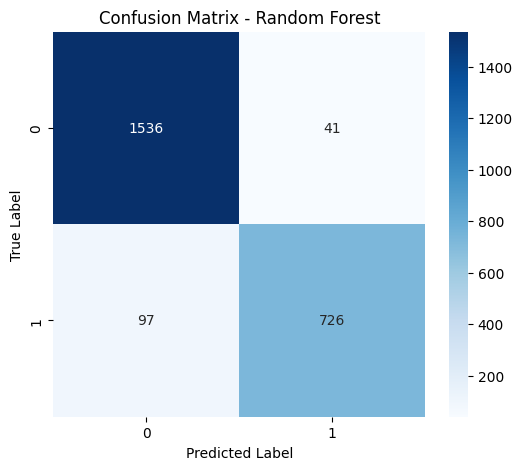

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1577
           1       0.95      0.88      0.91       823

    accuracy                           0.94      2400
   macro avg       0.94      0.93      0.94      2400
weighted avg       0.94      0.94      0.94      2400


Accuracy: 0.942500
F1 Score (weighted): 0.941989
Recall (weighted): 0.942500
Precision (weighted): 0.942639


In [15]:
# best_model = grid_search_rf.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy:.6f}")
print(f"F1 Score (weighted): {f1:.6f}")
print(f"Recall (weighted): {recall:.6f}")
print(f"Precision (weighted): {precision:.6f}")

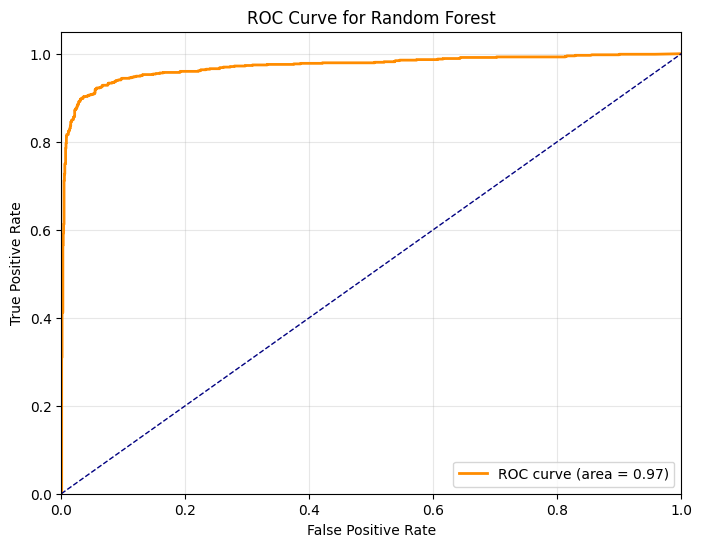

AUC:                       0.971454


In [ ]:
y_probs = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
print(f"AUC:                       {roc_auc:.6f}")
